In [52]:
import numpy as np
import pandas as pd
import os
import glob

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,     
    precision_score,      
    recall_score,           
    f1_score,              
    confusion_matrix,        
    classification_report,   
    roc_curve,               
    auc,                  
    roc_auc_score           
)


In [53]:
DATA_PATH = '/home/zarija/Desktop/ip2/datamining_env/grammatical+facial+expressions/grammatical_facial_expression/'

def load_all_data(data_path):
    datapoints_files = sorted(glob.glob(os.path.join(data_path, '*_datapoints.txt')))
    print(f"pronadjeno {len(datapoints_files)} fajlova.\n")

    all_data = []
    metadata = {
        'users': [],
        'expressions': [],
        'total_frames':0,
        'files_loaded': 0
    }

    for dp_file in datapoints_files:
        filename = os.path.basename(dp_file)
        parts = filename.replace('_datapoints.txt', '').split('_')
        user = parts[0]
        expression = '_'.join(parts[1:])

        target_file = dp_file.replace('_datapoints.txt', '_targets.txt')
        try:
            df_points = pd.read_csv(dp_file, sep=' ', header=0)
    
            df_targets = pd.read_csv(target_file, sep=' ', header=None, names=['label'])
    
            df_points['user'] = user
            df_points['expression'] = expression
            df_points['label'] = df_targets['label'].values
    
            all_data.append(df_points)
    
            if user not in metadata['users']:
                metadata['users'].append(user)
            if expression not in metadata['expressions']:
                metadata['expressions'].append(expression)
            metadata['total_frames'] += len(df_points)
            metadata['files_loaded'] += 1
    
            print(f"{filename}: {len(df_points)} frame-ova, Label sum: {df_targets['label'].sum()}")
        except Exception as e:
            print(f"greska pri ucitavanju {filename} : {e}")

    df = pd.concat(all_data, ignore_index=True)

    print(f"\n{'='*60}")
    print(f" UKUPNO UČITANO:")
    print(f"   - Korisnici: {metadata['users']}")
    print(f"   - Ekspresije: {metadata['expressions']}")
    print(f"   - Ukupno frame-ova: {metadata['total_frames']}")
    print(f"   - Fajlova: {metadata['files_loaded']}")
    print(f"   - DataFrame shape: {df.shape}")
    print(f"{'='*60}\n")

    return df, metadata


In [54]:
df_raw, metadata = load_all_data(DATA_PATH)

pronadjeno 18 fajlova.

a_affirmative_datapoints.txt: 1062 frame-ova, Label sum: 414
a_conditional_datapoints.txt: 1907 frame-ova, Label sum: 548
a_doubt_question_datapoints.txt: 1312 frame-ova, Label sum: 491
a_emphasis_datapoints.txt: 1403 frame-ova, Label sum: 330
a_negative_datapoints.txt: 1124 frame-ova, Label sum: 528
a_relative_datapoints.txt: 2330 frame-ova, Label sum: 644
a_topics_datapoints.txt: 1796 frame-ova, Label sum: 360
a_wh_question_datapoints.txt: 1286 frame-ova, Label sum: 609
a_yn_question_datapoints.txt: 1390 frame-ova, Label sum: 532
b_affirmative_datapoints.txt: 1074 frame-ova, Label sum: 528
b_conditional_datapoints.txt: 2034 frame-ova, Label sum: 589
b_doubt_question_datapoints.txt: 1497 frame-ova, Label sum: 780
b_emphasis_datapoints.txt: 1344 frame-ova, Label sum: 531
b_negative_datapoints.txt: 1582 frame-ova, Label sum: 712
b_relative_datapoints.txt: 1904 frame-ova, Label sum: 550
b_topics_datapoints.txt: 1825 frame-ova, Label sum: 467
b_wh_question_datapoin

In [55]:
print("\n OSNOVNE INFORMACIJE O DATASETU:")
print(f"Shape: {df_raw.shape}")
print(f"Broj kolona: {df_raw.shape[1]}")
print(f"Broj redova (frame-ova): {df_raw.shape[0]}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n TIPOVI PODATAKA:")
print(df_raw.dtypes.value_counts())

print("\n PROVERA NEDOSTAJUĆIH VREDNOSTI:")
missing = df_raw.isnull().sum()
if missing.sum() == 0:
    print("Nema nedostajućih vrednosti!")
else:
    print(f"Pronađeno {missing.sum()} nedostajućih vrednosti:")
    print(missing[missing > 0])

print("\n DISTRIBUCIJA PO KORISNICIMA:")
print(df_raw['user'].value_counts())

print("\n DISTRIBUCIJA PO EKSPRESIJAMA:")
print(df_raw['expression'].value_counts().sort_values(ascending=False))

print("\n DISTRIBUCIJA LABELA (0 vs 1):")
print(df_raw['label'].value_counts())
print(f"\n   Procenat aktivnih ekspresija: {df_raw['label'].mean()*100:.2f}%")

print("\n  STATISTIKA KOORDINATA (primer prvih 10 kolona):")
coord_cols = [col for col in df_raw.columns if col not in ['user', 'expression', 'label']]
print(df_raw[coord_cols[:10]].describe())

print("\n" + "="*80)


 OSNOVNE INFORMACIJE O DATASETU:
Shape: (27936, 304)
Broj kolona: 304
Broj redova (frame-ova): 27936
Memory usage: 67.69 MB

 TIPOVI PODATAKA:
float64    201
int64      101
object       2
Name: count, dtype: int64

 PROVERA NEDOSTAJUĆIH VREDNOSTI:
Nema nedostajućih vrednosti!

 DISTRIBUCIJA PO KORISNICIMA:
user
b    14326
a    13610
Name: count, dtype: int64

 DISTRIBUCIJA PO EKSPRESIJAMA:
expression
relative          4234
conditional       3941
topics            3621
yn_question       3128
doubt_question    2809
emphasis          2747
negative          2706
wh_question       2614
affirmative       2136
Name: count, dtype: int64

 DISTRIBUCIJA LABELA (0 vs 1):
label
0    18059
1     9877
Name: count, dtype: int64

   Procenat aktivnih ekspresija: 35.36%

  STATISTIKA KOORDINATA (primer prvih 10 kolona):
                0.0            0x            0y            0z            1x  \
count  2.793600e+04  27936.000000  27936.000000  27936.000000  27936.000000   
mean   1.390796e+09    305

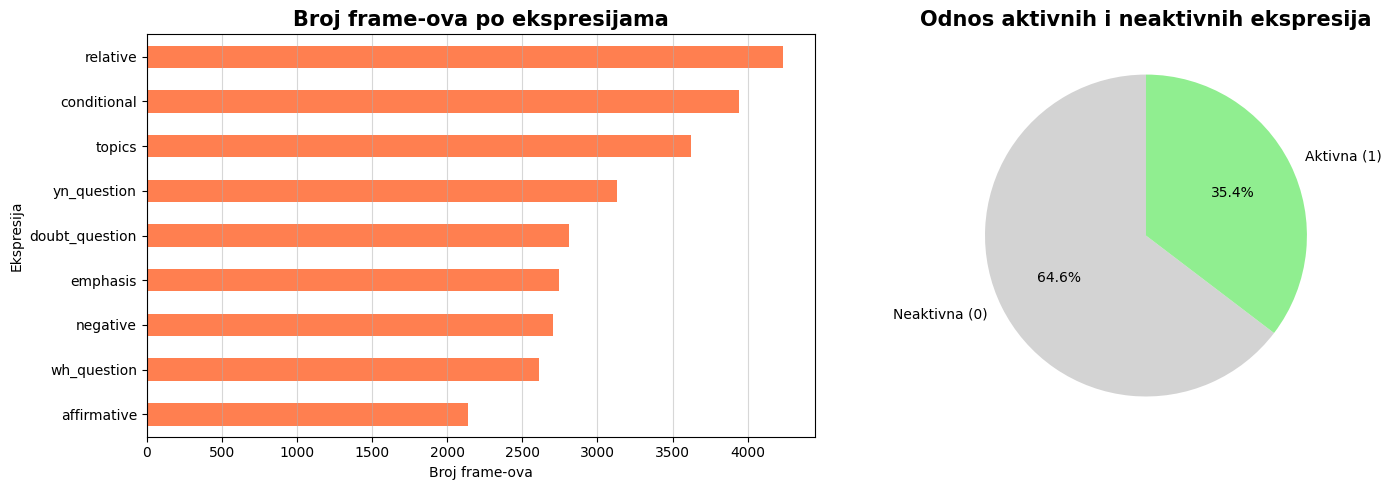

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_raw['expression'].value_counts().sort_values().plot(
    kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Broj frame-ova po ekspresijama', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Broj frame-ova')
axes[0].set_ylabel('Ekspresija')
axes[0].grid(axis='x', alpha=0.5)

label_counts = df_raw['label'].value_counts()
axes[1].pie(label_counts, 
            labels=['Neaktivna (0)', 'Aktivna (1)'], 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=['lightgray', 'lightgreen'])
axes[1].set_title('Odnos aktivnih i neaktivnih ekspresija', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucija.png', dpi=150, bbox_inches='tight')
plt.show()

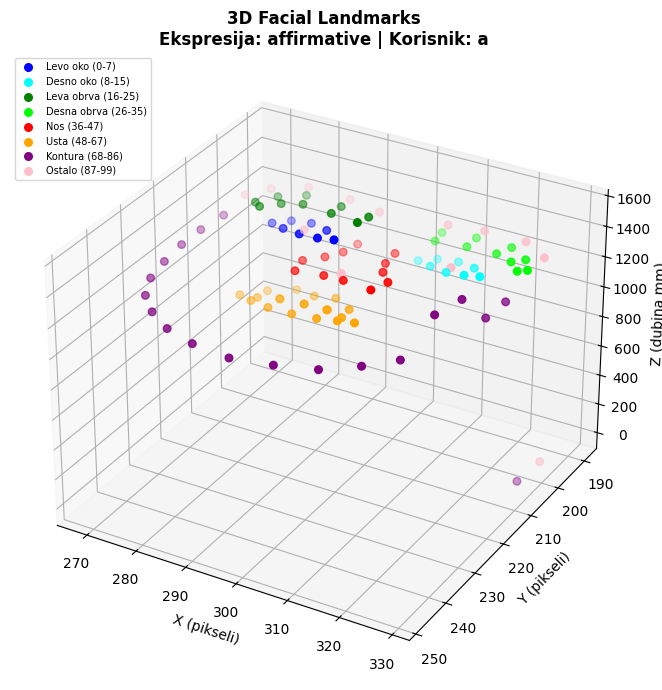

   Ekspresija: affirmative, Korisnik: a


In [57]:
sample_frame = df_raw[df_raw['label'] == 1].iloc[0]


x_coords = [sample_frame[f'{i}x'] for i in range(100)]
y_coords = [sample_frame[f'{i}y'] for i in range(100)]
z_coords = [sample_frame[f'{i}z'] for i in range(100)]

groups = {
    'Levo oko (0-7)':       (range(0, 8),    'blue'),
    'Desno oko (8-15)':     (range(8, 16),   'cyan'),
    'Leva obrva (16-25)':   (range(16, 26),  'green'),
    'Desna obrva (26-35)':  (range(26, 36),  'lime'),
    'Nos (36-47)':          (range(36, 48),  'red'),
    'Usta (48-67)':         (range(48, 68),  'orange'),
    'Kontura (68-86)':      (range(68, 87),  'purple'),
    'Ostalo (87-99)':       (range(87, 100), 'pink'),
}

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label_name, (indices, color) in groups.items():
    xs = [x_coords[i] for i in indices]
    ys = [y_coords[i] for i in indices]
    zs = [z_coords[i] for i in indices]
    ax.scatter(xs, ys, zs, c=color, label=label_name, s=30)

ax.set_xlabel('X (pikseli)')
ax.set_ylabel('Y (pikseli)')
ax.set_zlabel('Z (dubina mm)')
ax.set_title(f'3D Facial Landmarks\nEkspresija: {sample_frame["expression"]} | Korisnik: {sample_frame["user"]}',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=7)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('3d_landmarks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"   Ekspresija: {sample_frame['expression']}, Korisnik: {sample_frame['user']}")

In [58]:
print("PREPROCESSING - ČIŠĆENJE PODATAKA")

df = df_raw.copy()
df = df.drop(columns=['0.0'])

z_cols = df.filter(regex='z$').columns

df[z_cols] = df[z_cols].replace(0, np.nan)

df[z_cols] = df[z_cols].fillna(df[z_cols].median())

z_zeros_after = (df[z_cols] == 0).sum().sum()
print(f"Broj Z=0 vrednosti POSLE: {z_zeros_after}")

print("Preostalo NaN:", df.isnull().sum().sum())


PREPROCESSING - ČIŠĆENJE PODATAKA
Broj Z=0 vrednosti POSLE: 0
Preostalo NaN: 0


In [59]:
meta_cols = ['user', 'expression', 'label']
feature_cols = [col for col in df.columns if col not in meta_cols]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Čuvanje dataseta...")

df_raw.to_csv('dataset_original.csv', index=False)
print("dataset_original.csv")

df_scaled.to_csv('dataset_preprocessed.csv', index=False)
print("dataset_preprocessed.csv")

print("\n" + "="*80)
print("FINALNI PREGLED PREPROCESSINGA:")
print("="*80)
print(f"   Originalni dataset:     {df_raw.shape}")
print(f"   Preprocesirani dataset: {df_scaled.shape}")
print(f"\n   Koraci:")
print(f"   1. Uklonjen timestamp")
print(f"   2. Zamenjene Z=0 vrednosti sa median")
print(f"   3. Normalizacija (StandardScaler)")
print(f"   4. Dataseti sačuvani")

Čuvanje dataseta...
dataset_original.csv
dataset_preprocessed.csv

FINALNI PREGLED PREPROCESSINGA:
   Originalni dataset:     (27936, 304)
   Preprocesirani dataset: (27936, 303)

   Koraci:
   1. Uklonjen timestamp
   2. Zamenjene Z=0 vrednosti sa median
   3. Normalizacija (StandardScaler)
   4. Dataseti sačuvani


In [60]:
X = df_scaled[feature_cols].values
y_expression = df_scaled['expression'].values
y_label = df_scaled['label'].values

print(f"\n Ciljni atributi:")
print(f"   1. expression: {len(np.unique(y_expression))} klasa")
print(f"      Klase: {np.unique(y_expression)}")
print(f"   2. label: {len(np.unique(y_label))} klase (0 = neaktivna, 1 = aktivna)")


 Ciljni atributi:
   1. expression: 9 klasa
      Klase: ['affirmative' 'conditional' 'doubt_question' 'emphasis' 'negative'
 'relative' 'topics' 'wh_question' 'yn_question']
   2. label: 2 klase (0 = neaktivna, 1 = aktivna)


In [61]:
# PRIPREMA PODATAKA ZA MODELIRANJE
# ============================================================================

print("PRIPREMA PODATAKA ZA MODELIRANJE")
print("="*80)

print(f"\n Broj feature kolona: {len(feature_cols)}")
print(f"   Feature-i: koordinate facial landmarks (0x, 0y, 0z ... 99x, 99y, 99z)")

X = df_scaled[feature_cols].values

y_expression = df_scaled['expression'].values

y_label = df_scaled['label'].values

print(f"\n Ciljni atributi:")
print(f"   1. expression: {len(np.unique(y_expression))} klasa")
print(f"      Klase: {np.unique(y_expression)}")
print(f"   2. label: {len(np.unique(y_label))} klase (0 = neaktivna, 1 = aktivna)")

le_expression = LabelEncoder()
y_expression_encoded = le_expression.fit_transform(y_expression)

print(f"\nLabel Encoding za 'expression':")
for i, class_name in enumerate(le_expression.classes_):
    print(f"   {class_name} → {i}")

print(f"\n   Shape check:")
print(f"   X: {X.shape}")
print(f"   y_expression: {y_expression_encoded.shape}")
print(f"   y_label: {y_label.shape}")

PRIPREMA PODATAKA ZA MODELIRANJE

 Broj feature kolona: 300
   Feature-i: koordinate facial landmarks (0x, 0y, 0z ... 99x, 99y, 99z)

 Ciljni atributi:
   1. expression: 9 klasa
      Klase: ['affirmative' 'conditional' 'doubt_question' 'emphasis' 'negative'
 'relative' 'topics' 'wh_question' 'yn_question']
   2. label: 2 klase (0 = neaktivna, 1 = aktivna)

Label Encoding za 'expression':
   affirmative → 0
   conditional → 1
   doubt_question → 2
   emphasis → 3
   negative → 4
   relative → 5
   topics → 6
   wh_question → 7
   yn_question → 8

   Shape check:
   X: (27936, 300)
   y_expression: (27936,)
   y_label: (27936,)


In [62]:
# TRAIN/TEST SPLIT
# ============================================================================

print("✂️  TRAIN/TEST SPLIT")
print("="*80)

X_train_expr, X_test_expr, y_train_expr, y_test_expr = train_test_split(
    X, 
    y_expression_encoded,
    test_size=0.2,           
    random_state=42,       
    stratify=y_expression_encoded
)

print("\n CILJ A - Klasifikacija EXPRESSION (9 klasa):")
print(f"   Train set: {X_train_expr.shape[0]} samples")
print(f"   Test set:  {X_test_expr.shape[0]} samples")
print(f"\n   Distribucija klasa u train setu:")
unique, counts = np.unique(y_train_expr, return_counts=True)
for cls, cnt in zip(unique, counts):
    class_name = le_expression.classes_[cls]
    print(f"      {class_name}: {cnt} ({cnt/len(y_train_expr)*100:.1f}%)")


X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(
    X,
    y_label,
    test_size=0.2,
    random_state=42,
    stratify=y_label
)

print("\n CILJ B - Klasifikacija LABEL (0 vs 1):")
print(f"\n   Distribucija klasa u train setu:")
unique, counts = np.unique(y_train_label, return_counts=True)
for cls, cnt in zip(unique, counts):
    label_name = "Neaktivna" if cls == 0 else "Aktivna"
    print(f"      {label_name} ({cls}): {cnt} ({cnt/len(y_train_label)*100:.1f}%)")

print("\n Skaliranje (FIT na train, TRANSFORM na test)...")

scaler_expr = StandardScaler()
X_train_expr_scaled = scaler_expr.fit_transform(X_train_expr)
X_test_expr_scaled = scaler_expr.transform(X_test_expr)

scaler_label = StandardScaler()
X_train_label_scaled = scaler_label.fit_transform(X_train_label)
X_test_label_scaled = scaler_label.transform(X_test_label)

print("   Skaliranje završeno!")

✂️  TRAIN/TEST SPLIT

 CILJ A - Klasifikacija EXPRESSION (9 klasa):
   Train set: 22348 samples
   Test set:  5588 samples

   Distribucija klasa u train setu:
      affirmative: 1709 (7.6%)
      conditional: 3153 (14.1%)
      doubt_question: 2247 (10.1%)
      emphasis: 2197 (9.8%)
      negative: 2165 (9.7%)
      relative: 3387 (15.2%)
      topics: 2897 (13.0%)
      wh_question: 2091 (9.4%)
      yn_question: 2502 (11.2%)

 CILJ B - Klasifikacija LABEL (0 vs 1):

   Distribucija klasa u train setu:
      Neaktivna (0): 14447 (64.6%)
      Aktivna (1): 7901 (35.4%)

 Skaliranje (FIT na train, TRANSFORM na test)...
   Skaliranje završeno!


In [63]:
# FEATURE REDUCTION - Kreiranje redukovih skupova
# ============================================================================

print("="*80)
print(" FEATURE REDUCTION")
print("="*80)

print("\n SKUP 1 - SVI ATRIBUTI:")
print(f"   Broj feature-a: {X_train_expr_scaled.shape[1]}")

print("\n SKUP 2 - PCA REDUKCIJA:")

n_components = 50 

pca_expr = PCA(n_components=n_components, random_state=42)
X_train_expr_pca = pca_expr.fit_transform(X_train_expr_scaled)
X_test_expr_pca = pca_expr.transform(X_test_expr_scaled)

variance_explained = pca_expr.explained_variance_ratio_.sum()
print(f"   Expression - PCA({n_components}):")
print(f"   - Broj feature-a: {n_components}")
print(f"   - Objašnjava {variance_explained*100:.2f}% varijanse")

pca_label = PCA(n_components=n_components, random_state=42)
X_train_label_pca = pca_label.fit_transform(X_train_label_scaled)
X_test_label_pca = pca_label.transform(X_test_label_scaled)

variance_explained = pca_label.explained_variance_ratio_.sum()
print(f"   Label - PCA({n_components}):")
print(f"   - Broj feature-a: {n_components}")
print(f"   - Objašnjava {variance_explained*100:.2f}% varijanse")


print("\n SKUP 3 - SelectKBest (najbolji feature-i):")

k_best = 100 

selector_expr = SelectKBest(score_func=f_classif, k=k_best)
X_train_expr_kbest = selector_expr.fit_transform(X_train_expr_scaled, y_train_expr)
X_test_expr_kbest = selector_expr.transform(X_test_expr_scaled)

selected_features_expr = np.array(feature_cols)[selector_expr.get_support()]
print(f"   Expression - SelectKBest({k_best}):")
print(f"   - Broj feature-a: {k_best}")
print(f"   - Top 10 najboljih:")
feature_scores = selector_expr.scores_
top_10_indices = np.argsort(feature_scores)[-10:][::-1]
for idx in top_10_indices[:10]:
    print(f"      {feature_cols[idx]}: {feature_scores[idx]:.2f}")

selector_label = SelectKBest(score_func=f_classif, k=k_best)
X_train_label_kbest = selector_label.fit_transform(X_train_label_scaled, y_train_label)
X_test_label_kbest = selector_label.transform(X_test_label_scaled)

print(f"   Label - SelectKBest({k_best}):")
print(f"   - Broj feature-a: {k_best}")

print("SPREMNI DATASETOVI ZA MODELIRANJE:")
print("="*80)
print("\n CILJ A - Klasifikacija EXPRESSION (9 klasa):")
print(f"   1. Svi atributi:     Train={X_train_expr_scaled.shape}, Test={X_test_expr_scaled.shape}")
print(f"   2. PCA (50):         Train={X_train_expr_pca.shape}, Test={X_test_expr_pca.shape}")
print(f"   3. SelectKBest(100): Train={X_train_expr_kbest.shape}, Test={X_test_expr_kbest.shape}")

print("\n CILJ B - Klasifikacija LABEL (0 vs 1):")
print(f"   1. Svi atributi:     Train={X_train_label_scaled.shape}, Test={X_test_label_scaled.shape}")
print(f"   2. PCA (50):         Train={X_train_label_pca.shape}, Test={X_test_label_pca.shape}")
print(f"   3. SelectKBest(100): Train={X_train_label_kbest.shape}, Test={X_test_label_kbest.shape}")

 FEATURE REDUCTION

 SKUP 1 - SVI ATRIBUTI:
   Broj feature-a: 300

 SKUP 2 - PCA REDUKCIJA:
   Expression - PCA(50):
   - Broj feature-a: 50
   - Objašnjava 99.38% varijanse
   Label - PCA(50):
   - Broj feature-a: 50
   - Objašnjava 99.38% varijanse

 SKUP 3 - SelectKBest (najbolji feature-i):
   Expression - SelectKBest(100):
   - Broj feature-a: 100
   - Top 10 najboljih:
      41x: 362.00
      42x: 361.06
      52x: 360.05
      97x: 356.85
      51x: 356.70
      98x: 353.44
      40x: 350.04
      62x: 348.44
      50x: 348.15
      39x: 344.36
   Label - SelectKBest(100):
   - Broj feature-a: 100
SPREMNI DATASETOVI ZA MODELIRANJE:

 CILJ A - Klasifikacija EXPRESSION (9 klasa):
   1. Svi atributi:     Train=(22348, 300), Test=(5588, 300)
   2. PCA (50):         Train=(22348, 50), Test=(5588, 50)
   3. SelectKBest(100): Train=(22348, 100), Test=(5588, 100)

 CILJ B - Klasifikacija LABEL (0 vs 1):
   1. Svi atributi:     Train=(22348, 300), Test=(5588, 300)
   2. PCA (50):       

In [64]:
# HELPER FUNKCIJE I STORAGE ZA REZULTATE
# ============================================================================

results = []

def evaluate_model(model, X_train, X_test, y_train, y_test, 
                   model_name, feature_set, target_type):
    """
    Trenira model i vraća metrike performansi.
    
    Parametri:
    - model: sklearn model objekat
    - X_train, X_test, y_train, y_test: podaci
    - model_name: naziv modela (npr. "Logistic Regression")
    - feature_set: "All", "PCA", ili "KBest"
    - target_type: "Expression" ili "Label"
    
    Vraća dictionary sa metrikama
    """
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    if target_type == "Expression":
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    else:
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
    
    result = {
        'Model': model_name,
        'Feature_Set': feature_set,
        'Target': target_type,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Train_Samples': len(y_train),
        'Test_Samples': len(y_test),
        'Trained_Model': model
    }
    
    return result

def train_and_evaluate_all(model_name, model_expr_all, model_expr_pca, model_expr_kbest,
                           model_label_all, model_label_pca, model_label_kbest):
    """
    Treniramo model na svim kombinacijama (2 ciljne promenljive × 3 feature skupa = 6 modela).
    
    Parametri su 6 instanci modela (po jedna za svaku kombinaciju)
    """
    
    print(f"\n{'='*80}")
    print(f" {model_name}")
    print(f"{'='*80}")
    
    model_results = []
    
    print(f"\n CILJ A - Klasifikacija EXPRESSION (9 klasa):")
    
    print(f"   [1/3] Treniranje sa SVIM atributima (300)...")
    result = evaluate_model(
        model_expr_all, 
        X_train_expr_scaled, X_test_expr_scaled,
        y_train_expr, y_test_expr,
        model_name, "All_Features", "Expression"
    )
    model_results.append(result)
    print(f"         Accuracy: {result['Accuracy']:.4f}")
    
    print(f"   [2/3] Treniranje sa PCA (50)...")
    result = evaluate_model(
        model_expr_pca,
        X_train_expr_pca, X_test_expr_pca,
        y_train_expr, y_test_expr,
        model_name, "PCA_50", "Expression"
    )
    model_results.append(result)
    print(f"        Accuracy: {result['Accuracy']:.4f}")
    
    print(f"   [3/3] Treniranje sa SelectKBest (100)...")
    result = evaluate_model(
        model_expr_kbest,
        X_train_expr_kbest, X_test_expr_kbest,
        y_train_expr, y_test_expr,
        model_name, "KBest_100", "Expression"
    )
    model_results.append(result)
    print(f"       Accuracy: {result['Accuracy']:.4f}")
    
    print(f"\n CILJ B - Klasifikacija LABEL (0 vs 1):")
    
    print(f"   [1/3] Treniranje sa SVIM atributima (300)...")
    result = evaluate_model(
        model_label_all,
        X_train_label_scaled, X_test_label_scaled,
        y_train_label, y_test_label,
        model_name, "All_Features", "Label"
    )
    model_results.append(result)
    print(f"       Accuracy: {result['Accuracy']:.4f}")
    
    print(f"   [2/3] Treniranje sa PCA (50)...")
    result = evaluate_model(
        model_label_pca,
        X_train_label_pca, X_test_label_pca,
        y_train_label, y_test_label,
        model_name, "PCA_50", "Label"
    )
    model_results.append(result)
    print(f"       Accuracy: {result['Accuracy']:.4f}")
    
    print(f"   [3/3] Treniranje sa SelectKBest (100)...")
    result = evaluate_model(
        model_label_kbest,
        X_train_label_kbest, X_test_label_kbest,
        y_train_label, y_test_label,
        model_name, "KBest_100", "Label"
    )
    model_results.append(result)
    print(f"       Accuracy: {result['Accuracy']:.4f}")
    
    results.extend(model_results)
    
    print(f"\n {model_name} - Svih 6 modela trenirano!")
    
    return model_results

In [65]:
# MODEL 1: LOGISTIC REGRESSION
# ============================================================================

lr_expr_all = LogisticRegression(max_iter=3000, random_state=42)
lr_expr_pca = LogisticRegression(max_iter=3000, random_state=42)
lr_expr_kbest = LogisticRegression(max_iter=3000, random_state=42)

lr_label_all = LogisticRegression(max_iter=3000, random_state=42)
lr_label_pca = LogisticRegression(max_iter=3000, random_state=42)
lr_label_kbest = LogisticRegression(max_iter=3000, random_state=42)

lr_results = train_and_evaluate_all(
    "Logistic Regression",
    lr_expr_all, lr_expr_pca, lr_expr_kbest,
    lr_label_all, lr_label_pca, lr_label_kbest
)


 Logistic Regression

 CILJ A - Klasifikacija EXPRESSION (9 klasa):
   [1/3] Treniranje sa SVIM atributima (300)...
         Accuracy: 0.7836
   [2/3] Treniranje sa PCA (50)...
        Accuracy: 0.7155
   [3/3] Treniranje sa SelectKBest (100)...
       Accuracy: 0.6281

 CILJ B - Klasifikacija LABEL (0 vs 1):
   [1/3] Treniranje sa SVIM atributima (300)...
       Accuracy: 0.8373
   [2/3] Treniranje sa PCA (50)...
       Accuracy: 0.7990
   [3/3] Treniranje sa SelectKBest (100)...
       Accuracy: 0.8067

 Logistic Regression - Svih 6 modela trenirano!


In [66]:
# MODEL 2: K-NEAREST NEIGHBORS (KNN)
# ============================================================================

knn_expr_all = KNeighborsClassifier(n_neighbors=5)
knn_expr_pca = KNeighborsClassifier(n_neighbors=5)
knn_expr_kbest = KNeighborsClassifier(n_neighbors=5)

knn_label_all = KNeighborsClassifier(n_neighbors=5)
knn_label_pca = KNeighborsClassifier(n_neighbors=5)
knn_label_kbest = KNeighborsClassifier(n_neighbors=5)

knn_results = train_and_evaluate_all(
    "K-Nearest Neighbors",
    knn_expr_all, knn_expr_pca, knn_expr_kbest,
    knn_label_all, knn_label_pca, knn_label_kbest
)


 K-Nearest Neighbors

 CILJ A - Klasifikacija EXPRESSION (9 klasa):
   [1/3] Treniranje sa SVIM atributima (300)...
         Accuracy: 0.9406
   [2/3] Treniranje sa PCA (50)...
        Accuracy: 0.9408
   [3/3] Treniranje sa SelectKBest (100)...
       Accuracy: 0.9021

 CILJ B - Klasifikacija LABEL (0 vs 1):
   [1/3] Treniranje sa SVIM atributima (300)...
       Accuracy: 0.9091
   [2/3] Treniranje sa PCA (50)...
       Accuracy: 0.9069
   [3/3] Treniranje sa SelectKBest (100)...
       Accuracy: 0.9139

 K-Nearest Neighbors - Svih 6 modela trenirano!


In [67]:
# MODEL 3: DECISION TREE
# ============================================================================

dt_expr_all = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_expr_pca = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_expr_kbest = DecisionTreeClassifier(max_depth=10, random_state=42)

dt_label_all = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_label_pca = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_label_kbest = DecisionTreeClassifier(max_depth=10, random_state=42)

dt_results = train_and_evaluate_all(
    "Decision Tree",
    dt_expr_all, dt_expr_pca, dt_expr_kbest,
    dt_label_all, dt_label_pca, dt_label_kbest
)


 Decision Tree

 CILJ A - Klasifikacija EXPRESSION (9 klasa):
   [1/3] Treniranje sa SVIM atributima (300)...
         Accuracy: 0.8126
   [2/3] Treniranje sa PCA (50)...
        Accuracy: 0.7215
   [3/3] Treniranje sa SelectKBest (100)...
       Accuracy: 0.7176

 CILJ B - Klasifikacija LABEL (0 vs 1):
   [1/3] Treniranje sa SVIM atributima (300)...
       Accuracy: 0.8644
   [2/3] Treniranje sa PCA (50)...
       Accuracy: 0.8468
   [3/3] Treniranje sa SelectKBest (100)...
       Accuracy: 0.8801

 Decision Tree - Svih 6 modela trenirano!


In [68]:
# MODEL 4: SUPPORT VECTOR MACHINE (SVM)
# ============================================================================

svm_expr_all = SVC(kernel='rbf', C=1.0, random_state=42)
svm_expr_pca = SVC(kernel='rbf', C=1.0, random_state=42)
svm_expr_kbest = SVC(kernel='rbf', C=1.0, random_state=42)

svm_label_all = SVC(kernel='rbf', C=1.0, random_state=42)
svm_label_pca = SVC(kernel='rbf', C=1.0, random_state=42)
svm_label_kbest = SVC(kernel='rbf', C=1.0, random_state=42)

svm_results = train_and_evaluate_all(
    "Support Vector Machine",
    svm_expr_all, svm_expr_pca, svm_expr_kbest,
    svm_label_all, svm_label_pca, svm_label_kbest
)


 Support Vector Machine

 CILJ A - Klasifikacija EXPRESSION (9 klasa):
   [1/3] Treniranje sa SVIM atributima (300)...
         Accuracy: 0.9053
   [2/3] Treniranje sa PCA (50)...
        Accuracy: 0.8971
   [3/3] Treniranje sa SelectKBest (100)...
       Accuracy: 0.7554

 CILJ B - Klasifikacija LABEL (0 vs 1):
   [1/3] Treniranje sa SVIM atributima (300)...
       Accuracy: 0.8855
   [2/3] Treniranje sa PCA (50)...
       Accuracy: 0.8794
   [3/3] Treniranje sa SelectKBest (100)...
       Accuracy: 0.8695

 Support Vector Machine - Svih 6 modela trenirano!


In [ ]:
# MODEL 5: NEURAL NETWORK (Multi-Layer Perceptron)
# ============================================================================

nn_expr_all = MLPClassifier(hidden_layer_sizes=(100, 50), 
                            activation='relu', 
                            max_iter=500, 
                            random_state=42)
nn_expr_pca = MLPClassifier(hidden_layer_sizes=(100, 50), 
                           activation='relu', 
                           max_iter=500, 
                           random_state=42)
nn_expr_kbest = MLPClassifier(hidden_layer_sizes=(100, 50), 
                             activation='relu', 
                             max_iter=500, 
                             random_state=42)

nn_label_all = MLPClassifier(hidden_layer_sizes=(100, 50), 
                            activation='relu', 
                            max_iter=500, 
                            random_state=42)
nn_label_pca = MLPClassifier(hidden_layer_sizes=(100, 50), 
                            activation='relu', 
                            max_iter=500, 
                            random_state=42)
nn_label_kbest = MLPClassifier(hidden_layer_sizes=(100, 50), 
                              activation='relu', 
                              max_iter=500, 
                              random_state=42)

nn_results = train_and_evaluate_all(
    "Neural Network (MLP)",
    nn_expr_all, nn_expr_pca, nn_expr_kbest,
    nn_label_all, nn_label_pca, nn_label_kbest
)

In [ ]:
# AGREGACIJA REZULTATA
# ============================================================================

print("="*80)
print(" AGREGACIJA I ANALIZA REZULTATA")
print("="*80)

df_results = pd.DataFrame(results)

df_results_sorted = df_results.sort_values('Accuracy', ascending=False)

print("\n TOP 10 MODELA (po Accuracy):")
print(df_results_sorted[['Model', 'Feature_Set', 'Target', 'Accuracy', 
                          'Precision', 'Recall', 'F1_Score']].head(10).to_string(index=False))

print("\n PROSEČNE PERFORMANSE PO MODELU:")
model_stats = df_results.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean()
print(model_stats.sort_values('Accuracy', ascending=False).round(4))

print("\n PROSEČNE PERFORMANSE PO FEATURE SETU:")
feature_stats = df_results.groupby('Feature_Set')[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean()
print(feature_stats.sort_values('Accuracy', ascending=False).round(4))

print("\n PROSEČNE PERFORMANSE PO CILJU:")
target_stats = df_results.groupby('Target')[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean()
print(target_stats.round(4))

df_results.to_csv('model_results.csv', index=False)
print("\n Rezultati sačuvani u: model_results.csv")

In [ ]:
# VIZUALIZACIJA POREĐENJA MODELA
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_perf = df_results.groupby('Model')['Accuracy'].mean().sort_values(ascending=False)
axes[0,0].barh(model_perf.index, model_perf.values, color='skyblue')
axes[0,0].set_xlabel('Prosečna Accuracy')
axes[0,0].set_title('Poređenje algoritama (prosek svih kombinacija)', fontweight='bold')
axes[0,0].grid(axis='x', alpha=0.3)
for i, v in enumerate(model_perf.values):
    axes[0,0].text(v + 0.01, i, f'{v:.3f}', va='center')

feature_perf = df_results.groupby('Feature_Set')['Accuracy'].mean().sort_values()
axes[0,1].barh(feature_perf.index, feature_perf.values, color='coral')
axes[0,1].set_xlabel('Prosečna Accuracy')
axes[0,1].set_title('Poređenje feature setova', fontweight='bold')
axes[0,1].grid(axis='x', alpha=0.3)
for i, v in enumerate(feature_perf.values):
    axes[0,1].text(v + 0.01, i, f'{v:.3f}', va='center')

expr_results = df_results[df_results['Target'] == 'Expression']
heatmap_data = expr_results.pivot_table(values='Accuracy', 
                                         index='Model', 
                                         columns='Feature_Set')
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            ax=axes[1,0], vmin=0.6, vmax=1.0)
axes[1,0].set_title('Accuracy Heatmap - EXPRESSION (9 klasa)', fontweight='bold')

label_results = df_results[df_results['Target'] == 'Label']
heatmap_data2 = label_results.pivot_table(values='Accuracy', 
                                           index='Model', 
                                           columns='Feature_Set')
sns.heatmap(heatmap_data2, annot=True, fmt='.3f', cmap='RdYlGn', 
            ax=axes[1,1], vmin=0.6, vmax=1.0)
axes[1,1].set_title('Accuracy Heatmap - LABEL (0 vs 1)', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Vizualizacija sačuvana: model_comparison.png")

In [ ]:
# CONFUSION MATRIX - NAJBOLJI MODEL
# ============================================================================

# Pronalazimo najbolji model
best_row = df_results_sorted.iloc[0]
best_model_obj = best_row['Trained_Model']
best_model_name = best_row['Model']
best_feature_set = best_row['Feature_Set']
best_target = best_row['Target']

print(f" NAJBOLJI MODEL:")
print(f"   Algoritam: {best_model_name}")
print(f"   Feature Set: {best_feature_set}")
print(f"   Target: {best_target}")
print(f"   Accuracy: {best_row['Accuracy']:.4f}")
print(f"   F1-Score: {best_row['F1_Score']:.4f}")

if best_target == 'Expression':
    if best_feature_set == 'All_Features':
        X_test_best = X_test_expr_scaled
        y_test_best = y_test_expr
        class_names = le_expression.classes_
    elif best_feature_set == 'PCA_50':
        X_test_best = X_test_expr_pca
        y_test_best = y_test_expr
        class_names = le_expression.classes_
    else:  
        X_test_best = X_test_expr_kbest
        y_test_best = y_test_expr
        class_names = le_expression.classes_
else:  
    if best_feature_set == 'All_Features':
        X_test_best = X_test_label_scaled
        y_test_best = y_test_label
        class_names = ['Neaktivna (0)', 'Aktivna (1)']
    elif best_feature_set == 'PCA_50':
        X_test_best = X_test_label_pca
        y_test_best = y_test_label
        class_names = ['Neaktivna (0)', 'Aktivna (1)']
    else: 
        X_test_best = X_test_label_kbest
        y_test_best = y_test_label
        class_names = ['Neaktivna (0)', 'Aktivna (1)']

y_pred_best = best_model_obj.predict(X_test_best)

cm = confusion_matrix(y_test_best, y_pred_best)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names, ax=ax)
ax.set_xlabel('Predviđena klasa', fontsize=12)
ax.set_ylabel('Stvarna klasa', fontsize=12)
ax.set_title(f'Confusion Matrix - {best_model_name}\n({best_feature_set}, {best_target})', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n CLASSIFICATION REPORT:")
print(classification_report(y_test_best, y_pred_best, target_names=class_names))

print("\n Matrica konfuzije sačuvana: confusion_matrix_best.png")

In [ ]:
# ČUVANJE MODELA I OBJEKATA
# ============================================================================

import pickle
from datetime import datetime

print("="*80)
print("ČUVANJE MODELA")
print("="*80)

import os
os.makedirs('saved_models', exist_ok=True)

best_models = {}
for model_name in df_results['Model'].unique():
    model_results = df_results[df_results['Model'] == model_name]
    best_idx = model_results['Accuracy'].idxmax()
    best_models[model_name] = df_results.loc[best_idx]

for model_name, best_row in best_models.items():
    model_obj = best_row['Trained_Model']
    feature_set = best_row['Feature_Set']
    target = best_row['Target']
    accuracy = best_row['Accuracy']
    
    safe_name = model_name.replace(' ', '_').replace('(', '').replace(')', '')
    filename = f"saved_models/{safe_name}_{feature_set}_{target}.pkl"
    
    with open(filename, 'wb') as f:
        pickle.dump(model_obj, f)
    
    print(f"   {model_name}: {filename}")
    print(f"   Feature Set: {feature_set}, Target: {target}, Accuracy: {accuracy:.4f}")

print("\n ČUVANJE PREPROCESSING OBJEKATA:")

with open('saved_models/scaler_expression.pkl', 'wb') as f:
    pickle.dump(scaler_expr, f)
print("    scaler_expression.pkl")

with open('saved_models/scaler_label.pkl', 'wb') as f:
    pickle.dump(scaler_label, f)
print("    scaler_label.pkl")

with open('saved_models/pca_expression.pkl', 'wb') as f:
    pickle.dump(pca_expr, f)
print("    pca_expression.pkl")

with open('saved_models/pca_label.pkl', 'wb') as f:
    pickle.dump(pca_label, f)
print("    pca_label.pkl")

with open('saved_models/selector_expression.pkl', 'wb') as f:
    pickle.dump(selector_expr, f)
print("    selector_expression.pkl")

with open('saved_models/selector_label.pkl', 'wb') as f:
    pickle.dump(selector_label, f)
print("    selector_label.pkl")

with open('saved_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le_expression, f)
print("    label_encoder.pkl")

metadata = {
    'project': 'Grammatical Facial Expressions Classification',
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'best_model': 'Neural Network (MLP) with PCA_50',
    'best_accuracy': 0.9678,
    'dataset_shape': df_raw.shape,
    'num_models_trained': len(results),
    'algorithms': list(df_results['Model'].unique()),
    'feature_sets': list(df_results['Feature_Set'].unique()),
    'targets': list(df_results['Target'].unique())
}

with open('saved_models/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("    metadata.pkl")

print("\n" + "="*80)
print("SVI MODELI I OBJEKTI SAČUVANI U: saved_models/")